In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

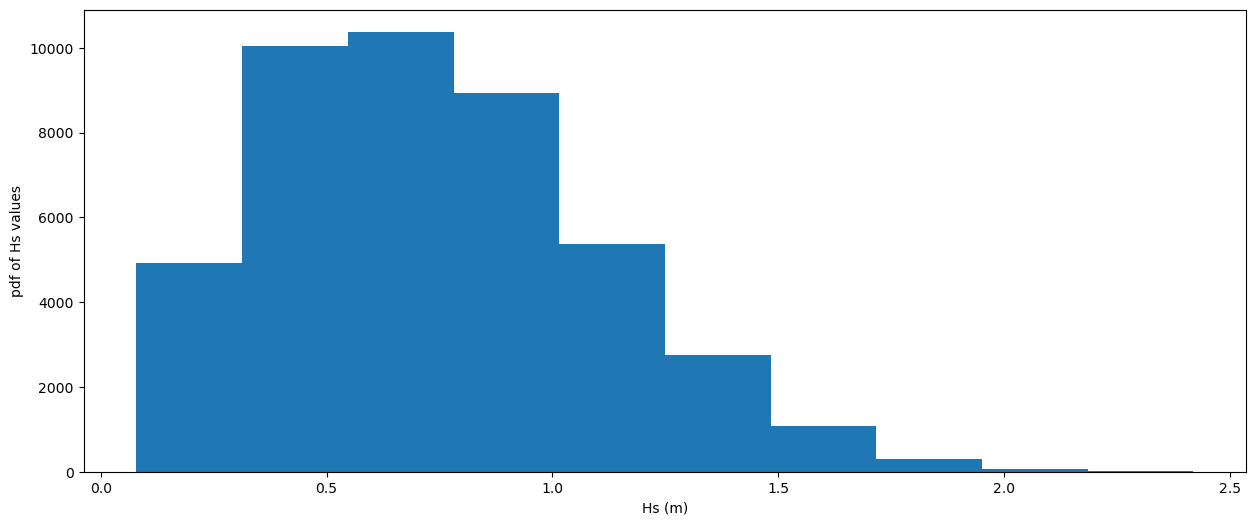

Number of Hs values:  43832

0       1996-01-01 00:00:00
1       1996-01-01 06:00:00
2       1996-01-01 12:00:00
3       1996-01-01 18:00:00
4       1996-01-02 00:00:00
                ...        
43827   2025-12-30 18:00:00
43828   2025-12-31 00:00:00
43829   2025-12-31 06:00:00
43830   2025-12-31 12:00:00
43831   2025-12-31 18:00:00
Name: time, Length: 43832, dtype: datetime64[ns]


In [2]:
wave_data = pd.read_csv('total_data.csv')

wave_data["time"] = pd.to_datetime(wave_data["time"])

time_series = wave_data["Hs_combined"]
period_series = wave_data["Peak_period"]
time_values = wave_data["time"]
# 
#  Extract Hs from database and plot histogram
#

fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs values')
ax.hist(time_series, histtype='stepfilled')
plt.show()

#
imax = len(time_series)
print('Number of Hs values: ',imax)
print()
dft = wave_data.get("time")
print(dft)
pass

In [3]:
#
# Peak Over Through code
def pot_method(data, threshold, dtime):
    idx_pot, _ = find_peaks(data, height = threshold, distance = dtime)
    pot_list = data.loc[idx_pot]
    return idx_pot, pot_list
#

figwave = go.Figure()

figwave.add_trace(go.Scatter(
    x=time_values,
    y=time_series,
    mode='lines',
    name='Hs time series'
))

figwave.update_layout(
    xaxis_title='Date',
    yaxis_title='Hs [m]',
    title='Significant wave height time series'
)

figwave.show()

In [4]:
#
# threshold is the Hs threshold value
# dtime is the number of values used in time
#
threshold = 1.0
dtime = 12
tare = threshold

indices,pot_maxima = pot_method(time_series, threshold, dtime)

kmax = len(pot_maxima)
print("Number of peaks based on Threshold: ",threshold," and time ",dtime," is ",kmax)
print('Last part of the calculated Peaks over Threshold values: ')
print(pot_maxima.tail())

Number of peaks based on Threshold:  1.0  and time  12  is  1473
Last part of the calculated Peaks over Threshold values: 
43733    1.461322
43746    1.154401
43766    1.207757
43790    1.698357
43810    1.154488
Name: Hs_combined, dtype: float64


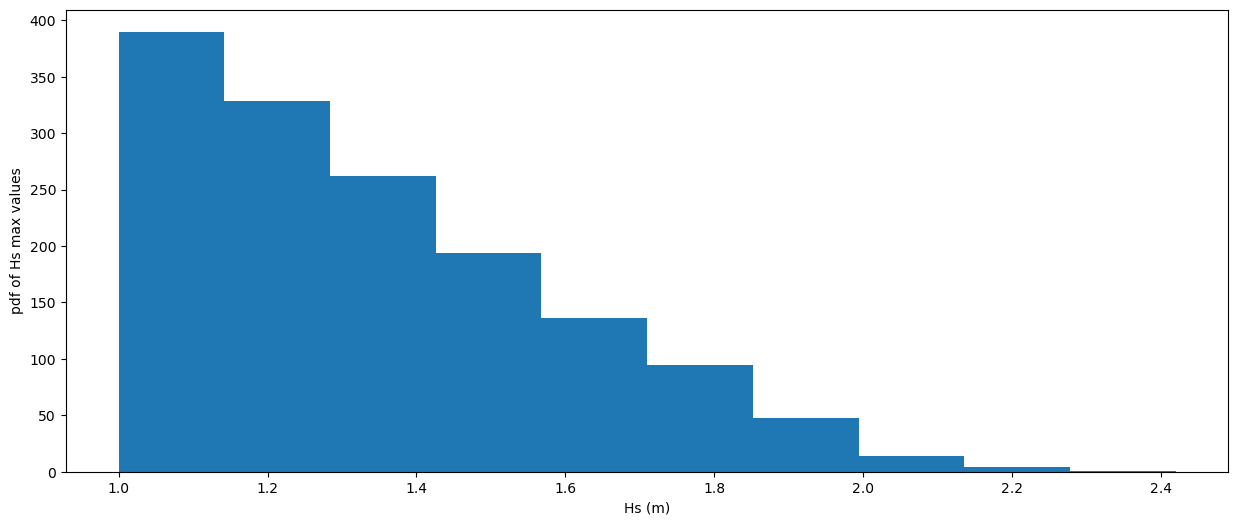

In [5]:
#
#
# following is a subsegment to extract part of the data for visualization
# NB: j is starting value op peaks and range is number of points to be visualized
#
sub_ind = []
j = 20

for i in range(0, 24):
    k = j + i
    val = indices[k]
    sub_ind.append(val)

sub_pot = pot_maxima.loc[sub_ind]

#
# Use dtime as extra space around the selected peaks
#
inst = max(sub_ind[0] - dtime, 0)
inen = min(sub_ind[23] + dtime, len(time_series) - 1)

sub_tim = time_series.iloc[inst:inen+1]
sub_dates = dft.iloc[inst:inen+1]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sub_dates,
    y=sub_tim,
    mode='lines',
    name='Original Plot'
))

fig.add_trace(go.Scatter(
    x=dft.iloc[sub_ind],
    y=sub_pot,
    mode='markers',
    marker=dict(
        size=8,
        color='red',
        symbol='cross'
    ),
    name='Detected Peaks'
))

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Hs [m]',
    title='Detected POT Peaks'
)

fig.show()

#
pot_time = []
for i in range(0,kmax):
    val = indices[i]
    pot_time.append(dft[val])
#
fig, ax = plt.subplots(1, 1)
plt.xlabel('Hs (m)')
plt.ylabel('pdf of Hs max values')
ax.hist(pot_maxima, histtype='stepfilled')
plt.show()
#
pass

In [6]:
array = np.array([indices, 
         pot_time,
         pot_maxima,
         period_series.loc[indices]
         ])

array = array.T

df = pd.DataFrame(array, columns=['index', 'pot_time', 'pot_maxima', 'Peak_period'])

df.to_csv('EVA result POT combined.csv', index=False)


In [7]:
import reliability.Fitters as rf

In [8]:
dfmax = []
for it in pot_maxima.items():
    val = it[1] - tare # pot_maxima[i]
    dfmax.append(val)    
dfmax.sort()

Results from Fit_Weibull_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1473/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         0.37068      0.00794491  0.355431  0.386583
     Beta         1.27558       0.0269582   1.22382   1.32953 

Goodness of fit    Value
 Log-likelihood  153.828
           AICc -303.647
            BIC -293.065
             AD  4.28044 



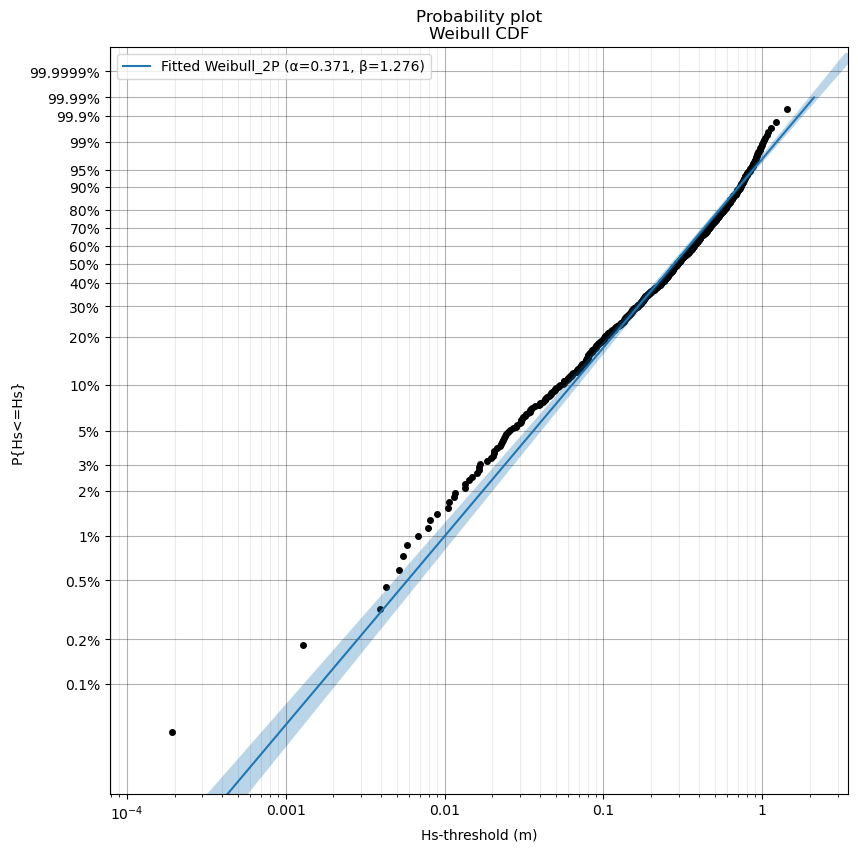

In [9]:
waw2 = rf.Fit_Weibull_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

Results from Fit_Weibull_3P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1473/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         0.37068      0.00794491  0.355431  0.386583
     Beta         1.27558       0.0269582   1.22382   1.32953
    Gamma               0               0         0         0 

Goodness of fit    Value
 Log-likelihood  153.828
           AICc -301.639
            BIC  -285.77
             AD  4.28044 



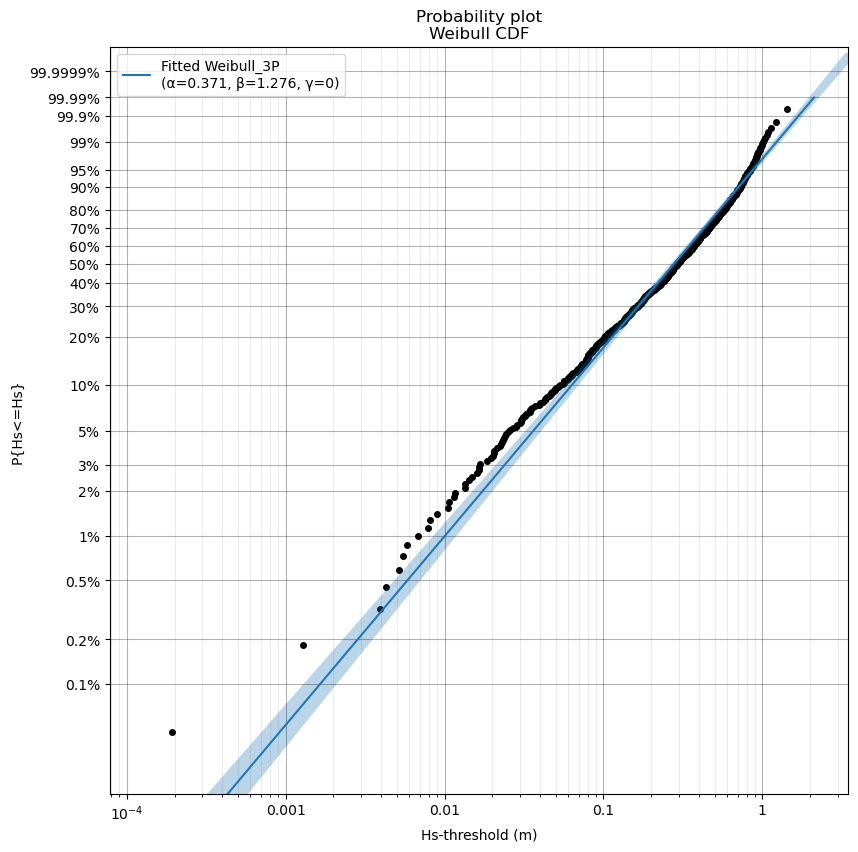

In [10]:
#
#  Weibull 3P fit delivers alpha = scale factor, beta = shape factor & gamma = location factor

waw3 = rf.Fit_Weibull_3P(failures=dfmax)

plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()


Results from Fit_Gumbel_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1473/0 (0% right censored) 

Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
       Mu        0.480887      0.00801299  0.465182  0.496592
    Sigma        0.289069      0.00515917  0.279132  0.299359 

Goodness of fit    Value
 Log-likelihood -337.023
           AICc  678.053
            BIC  688.635
             AD  56.8998 



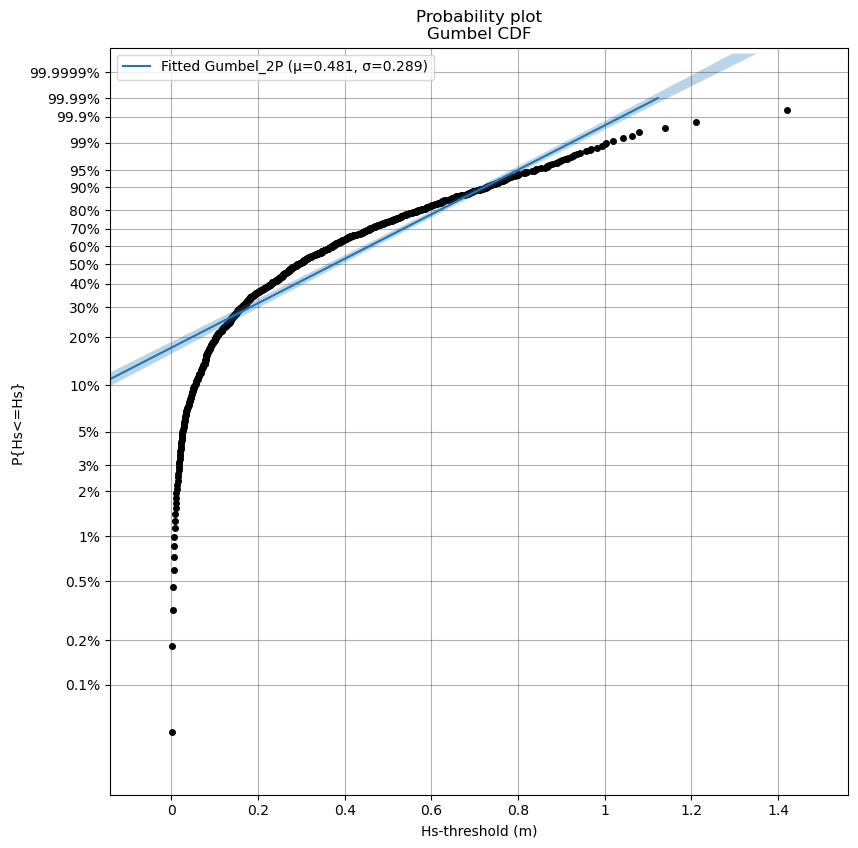

In [11]:
wag = rf.Fit_Gumbel_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

Results from Fit_Exponential_2P (95% CI):
Analysis method: Maximum Likelihood Estimation (MLE)
Optimizer: TNC
Failures / Right censored: 1473/0 (0% right censored) 

Parameter  Point Estimate  Standard Error    Lower CI    Upper CI
   Lambda         2.89885       0.0755308     2.75453     3.05073
 1/Lambda        0.344965      0.00898821     0.32779    0.363039
    Gamma     9.15693e-05               0 9.15693e-05 9.15693e-05 

Goodness of fit    Value
 Log-likelihood  94.7336
           AICc -185.459
            BIC -174.877
             AD  23.9866 



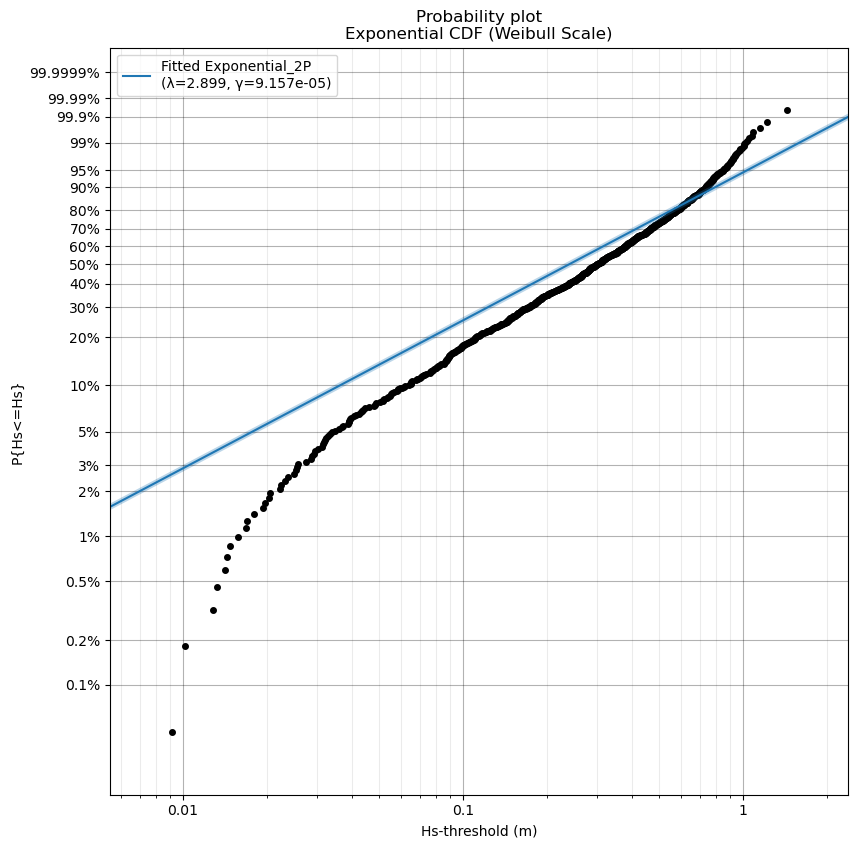

In [12]:
wae = rf.Fit_Exponential_2P(failures=dfmax)
plt.ylabel('P{Hs<=Hs}')
plt.xlabel('Hs-threshold (m)')
plt.show()

In [13]:
#
#  Determine return period values
#
#
# define exceedance value for 100 yr return
# 
treturn = 200
numberyears = 30
numb = len(pot_maxima) / numberyears
prob = 1 - 1/(numb * treturn)
print(prob)

0.99989816700611


In [14]:
# Weibull 2
X_lower,X_point,X_upper = waw2.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull2P ',treturn,'Year return value is ',X_point,' (m)')

# Weibull 3
X_lower,X_point,X_upper = waw3.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Weibull3P ',treturn,'Year return value is ',X_point,' (m)')

# Gumbel
X_lower,X_point,X_upper = wag.distribution.CDF(CI_type='time',CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Gumbel ',treturn,'Year return value is ',X_point,' (m)')

# Exponential
X_lower,X_point,X_upper = wae.distribution.CDF(CI_y=prob,show_plot=False)
X_point = X_point + tare ## IMP
print('Exponential ',treturn,'Year return value is ',X_point,' (m)')

Weibull2P  200 Year return value is  3.109981180306105  (m)
Weibull3P  200 Year return value is  3.109981180306105  (m)
Gumbel  200 Year return value is  2.122143101761944  (m)
Exponential  200 Year return value is  4.17106731021434  (m)


c:\Users\jholl\tudelft-conda\envs\mude-base\Lib\site-packages\reliability\Fitters.py:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(


Results from Fit_Everything:
Analysis method: MLE
Failures / Right censored: 1473/0 (0% right censored) 

   Distribution    Alpha    Beta       Gamma  Alpha 1  Beta 1  Alpha 2  Beta 2 Proportion 1 DS       Mu    Sigma  Lambda  Log-likelihood     AICc      BIC       AD optimizer
     Weibull_CR                              0.418449 1.09701 0.866036  3.7443                                                   184.071 -360.115 -338.962 0.161205       TNC
Weibull_Mixture                              0.238877 1.17163 0.603716 2.52562     0.615911                                      183.394 -356.748 -330.313 0.253742       TNC
     Weibull_2P  0.37068 1.27558                                                                                                 153.828 -303.647 -293.065  4.28044       TNC
     Weibull_DS  0.37068 1.27558                                                             1                                   153.828 -301.639  -285.77  4.28044       TNC
     Weibull_3P  0.37068

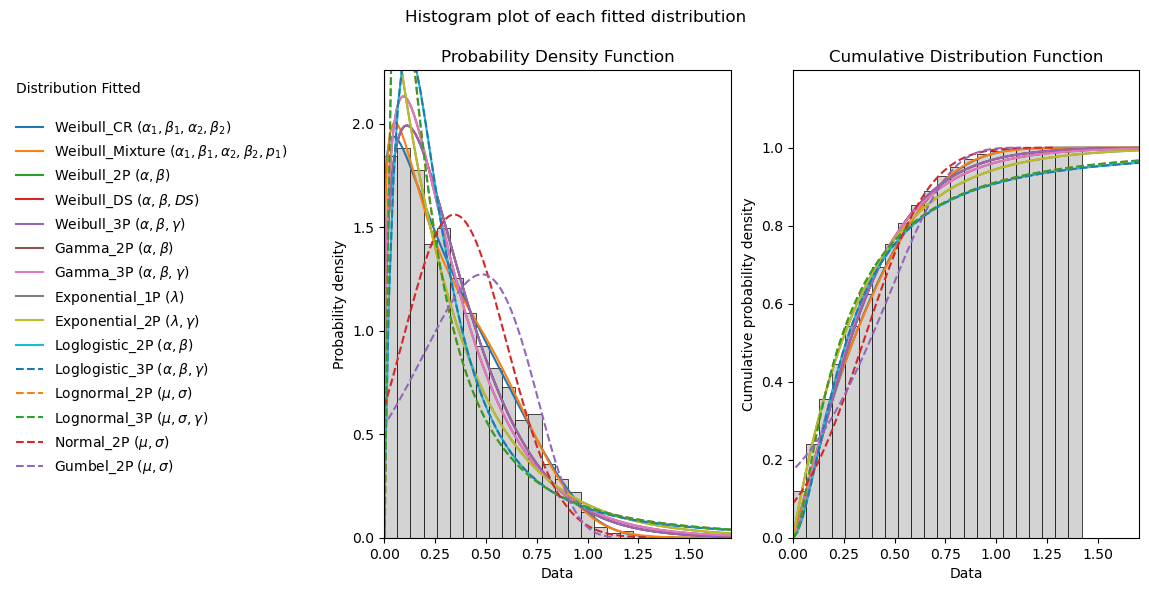

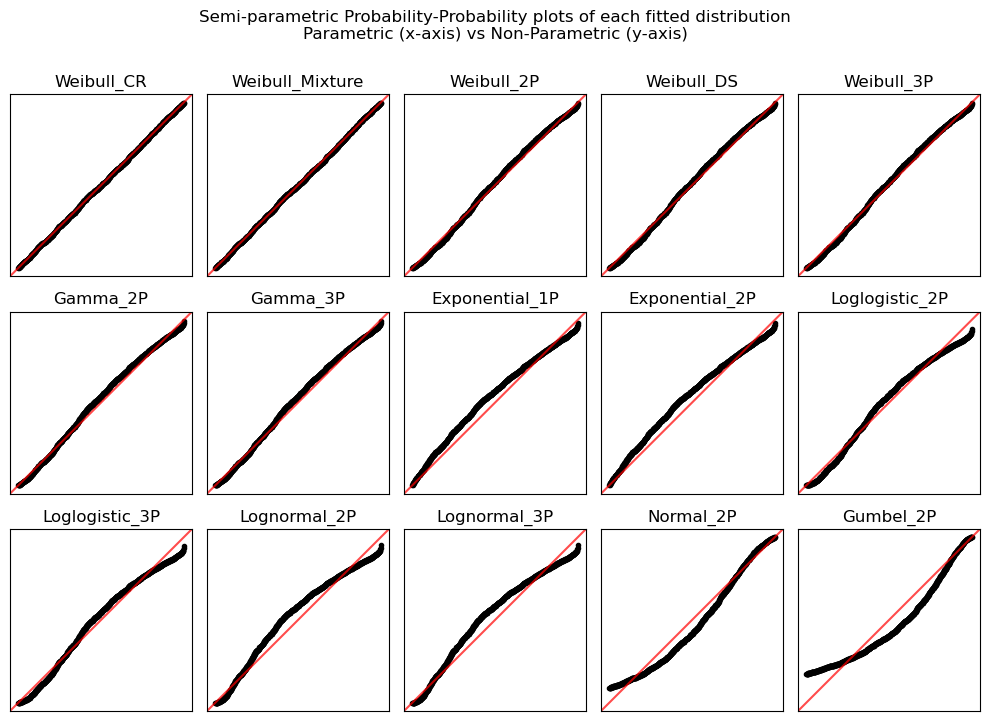

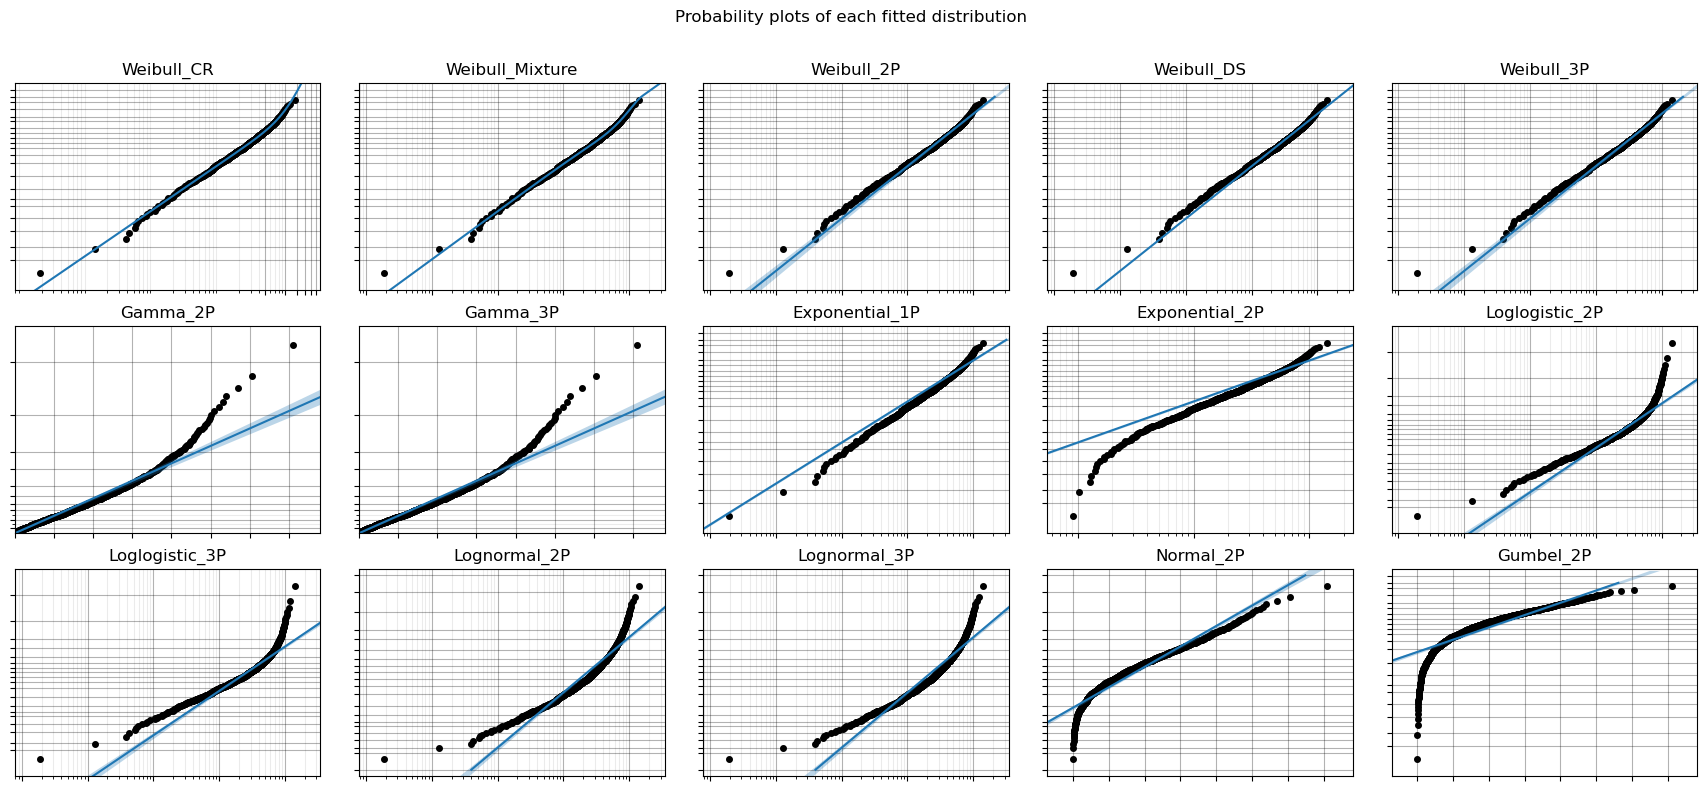

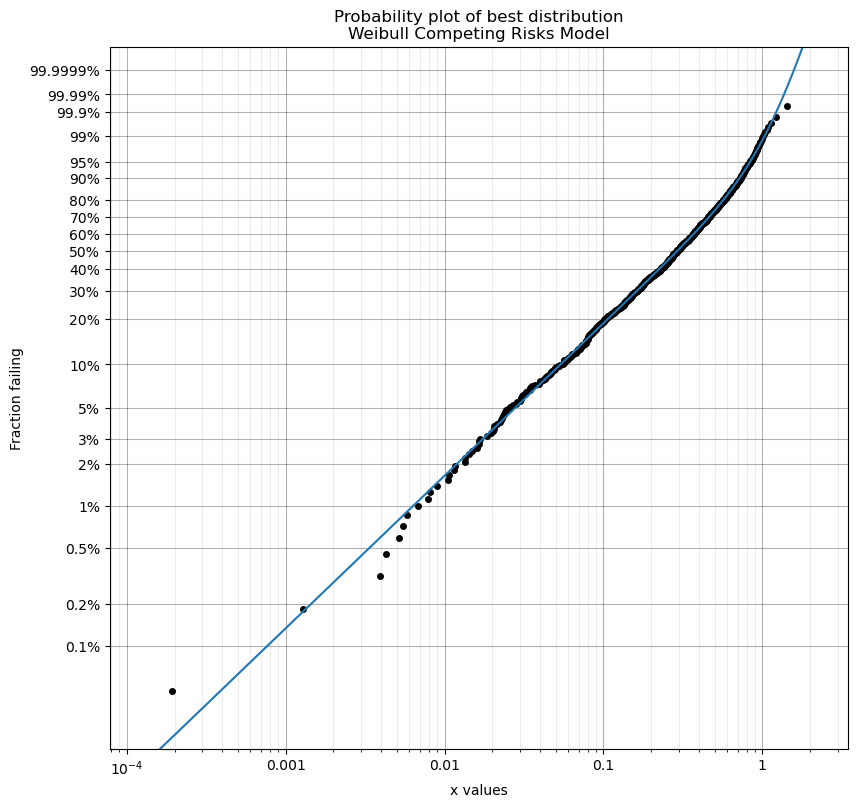

The best fitting distribution was: Weibull_CR


,Distribution,Alpha,Beta,Gamma,...,AICc,BIC,AD,optimizer
0,Weibull_CR,,,,...,-360.115,-338.962,0.161205,TNC
0,Weibull_Mixture,,,,...,-356.748,-330.313,0.253742,TNC
0,Weibull_2P,0.37068,1.27558,,...,-303.647,-293.065,4.28044,TNC
0,Weibull_DS,0.37068,1.27558,,...,-301.639,-285.77,4.28044,TNC
0,Weibull_3P,0.37068,1.27558,0,...,-301.639,-285.77,4.28044,TNC
0,Gamma_2P,0.250578,1.37704,,...,-269.249,-258.667,6.60478,TNC
0,Gamma_3P,0.250578,1.37704,0,...,-267.241,-251.372,6.60478,L-BFGS-B
0,Exponential_1P,,,,...,-186.683,-181.39,24.0538,TNC
0,Exponential_2P,,,9.15693e-05,...,-185.459,-174.877,23.9866,TNC
0,Loglogistic_2P,0.260665,1.70743,,...,11.0434,21.6254,20.3226,TNC


In [15]:
results = rf.Fit_Everything(failures=dfmax)

print("The best fitting distribution was:", results.best_distribution_name)

display(results.results)

In [16]:
from pyextremes import plot_parameter_stability
from pyextremes.plotting import plot_extremes
from pyextremes import EVA
from pyextremes import get_extremes
from pyextremes import plot_threshold_stability

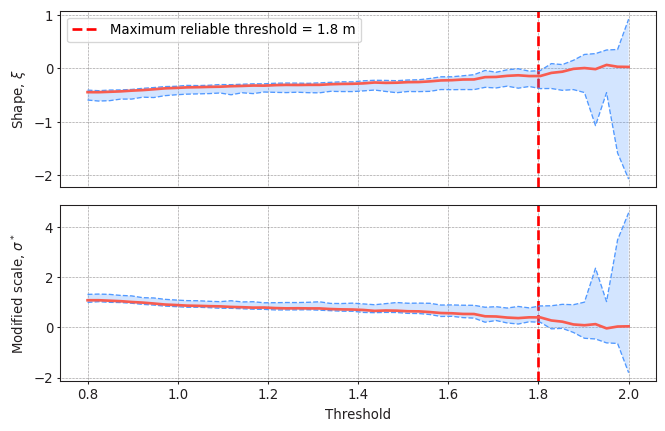

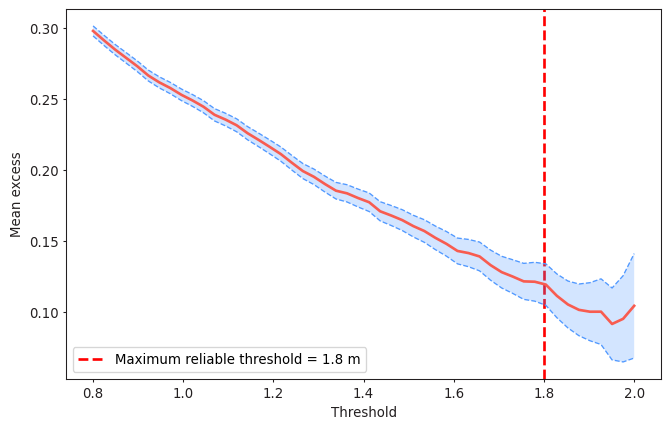

In [17]:
# ============================================================
# THRESHOLD CHECK - WS2 / pyExtremes method
# ============================================================
from pyextremes import plot_parameter_stability, plot_mean_residual_life

data = (
    wave_data[["time", "Hs_combined"]]
    .dropna()
    .assign(time=lambda df: pd.to_datetime(df["time"]))
    .set_index("time")["Hs_combined"]
    .sort_index()
)
data.name = "Hs"

r = "72H"
maximum_threshold = 1.8

# realistic threshold range in metres
thresholds = np.linspace(0.8, 2, 50)

# Parameter stability plot
plot_parameter_stability(
    data,
    thresholds=thresholds,
    r=r,
    alpha=0.95
)

for ax in plt.gcf().axes:
    ax.axvline(
        maximum_threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Maximum reliable threshold = {maximum_threshold:.1f} m"
    )

for ax in plt.gcf().axes:
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend()
        break

plt.show()

# Mean residual life plot
plot_mean_residual_life(
    data,
    thresholds=thresholds
)

for ax in plt.gcf().axes:
    ax.axvline(
        maximum_threshold,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Maximum reliable threshold = {maximum_threshold:.1f} m"
    )
    ax.legend()

plt.show()

In [18]:
pot_df = pd.read_csv("EVA result POT combined.csv")
pot_df["pot_time"] = pd.to_datetime(pot_df["pot_time"])

threshold = 1.0
pot_maxima = pot_df["pot_maxima"].astype(float)
excess = pot_maxima - threshold

pot_df["dt_hours"] = pot_df["pot_time"].diff().dt.total_seconds() / 3600

print("Number of POT peaks:", len(pot_df))
print("Minimum time spacing [h]:", pot_df["dt_hours"].min())
print("Number of peaks closer than 72 h:", (pot_df["dt_hours"] < 72).sum())

Number of POT peaks: 1473
Minimum time spacing [h]: 72.0
Number of peaks closer than 72 h: 0


In [19]:
# ============================================================
# FIT GPD TO POT EXCESSES
# ============================================================

from scipy import stats

gpd_shape, gpd_loc, gpd_scale = stats.genpareto.fit(excess, floc=0)

print("GPD shape ξ:", gpd_shape)
print("GPD scale σ:", gpd_scale)
print("GPD location:", gpd_loc)

if gpd_shape < 0:
    upper_bound = threshold - gpd_scale / gpd_shape
    print("Upper bound Hs:", upper_bound)

GPD shape ξ: -0.30476185954706736
GPD scale σ: 0.44350679607279997
GPD location: 0
Upper bound Hs: 2.455256890517512


In [20]:
# ============================================================
# RETURN VALUES
# ============================================================

record_years = (
    wave_data["time"].max() - wave_data["time"].min()
).total_seconds() / (365.2425 * 24 * 3600)

lambda_pot = len(pot_maxima) / record_years

print("Record length [years]:", record_years)
print("POT peaks per year λ:", lambda_pot)

def pot_gpd_return_value(R):
    p_non_exceed_excess = 1 - 1 / (lambda_pot * R)
    return threshold + stats.genpareto.ppf(
        p_non_exceed_excess,
        c=gpd_shape,
        loc=0,
        scale=gpd_scale
    )

return_periods = [1, 10, 50, 100, 200, 490, 500, 1000, 10000]

design_table = pd.DataFrame({
    "Return period [years]": return_periods,
    "Hs POT-GPD [m]": [pot_gpd_return_value(R) for R in return_periods]
})

design_table["Hs POT-GPD [m]"] = design_table["Hs POT-GPD [m]"].round(3)

display(design_table)

Record length [years]: 30.00130050582832
POT peaks per year λ: 49.09787159772764


,Return period [years],Hs POT-GPD [m]
0,1,2.011
1,10,2.235
2,50,2.32
3,100,2.346
4,200,2.367
5,490,2.388
6,500,2.388
7,1000,2.401
8,10000,2.428


In [21]:
# ============================================================
# SCATTERPLOT: PERIOD VS WAVE HEIGHT
# Full dataset + detected POT peaks
# ============================================================

import plotly.graph_objects as go

# Use the correct period column
period_series = wave_data["Peak_period"]

fig = go.Figure()

# All wave data points
fig.add_trace(go.Scatter(
    x=period_series,
    y=time_series,
    mode="markers",
    marker=dict(
        size=4,
        opacity=0.35,
        color="blue"
    ),
    name="All wave data"
))

# POT peaks with corresponding period at the same index/timestamp
fig.add_trace(go.Scatter(
    x=period_series.iloc[indices],
    y=pot_maxima.values,
    mode="markers",
    marker=dict(
        size=8,
        color="red",
        symbol="cross"
    ),
    name="Detected POT peaks"
))

fig.update_layout(
    title="Wave height vs peak wave period",
    xaxis_title="Peak wave period Tp [s]",
    yaxis_title="Significant wave height Hs [m]",
    template="plotly_white"
)

fig.show()